Import Libraries

In [2]:
!pip install yfinance
import pandas as pd
import numpy as np
import datetime as dt

# from nsepy import get_history as gh # This library is causing SSL issues, switching to yfinance
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.ar_model import AutoReg

import matplotlib.pyplot as plt

Download Asian Paints Data

In [3]:
start = dt.datetime(2020,1,1)
end   = dt.datetime(2023,1,1)

# Using yfinance to download data as nsepy is encountering SSL errors
stk_data = yf.download(
    tickers='ASIANPAINT.NS',
    start=start,
    end=end
)

/tmp/ipykernel_670/4151275368.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stk_data = yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data.head()

Price,Close,High,Low,Open,Volume
Ticker,ASIANPAINT.NS,ASIANPAINT.NS,ASIANPAINT.NS,ASIANPAINT.NS,ASIANPAINT.NS
Date,,,,,
2020-01-01,1705.415527,1714.307900,1695.905068,1702.562390,397285
2020-01-02,1702.990479,1711.787654,1696.095395,1703.323321,411266
2020-01-03,1665.661743,1692.671469,1661.524717,1692.671469,1318628
2020-01-06,1623.577881,1652.917621,1611.071605,1652.870022,1871804
2020-01-07,1639.983398,1655.295213,1627.239362,1627.239362,1033650


Select Required Columns

In [5]:
stk_data = stk_data[['Open','High','Low','Close']]

In [6]:
stk_data

Price,Open,High,Low,Close
Ticker,ASIANPAINT.NS,ASIANPAINT.NS,ASIANPAINT.NS,ASIANPAINT.NS
Date,,,,
2020-01-01,1702.562390,1714.307900,1695.905068,1705.415527
2020-01-02,1703.323321,1711.787654,1696.095395,1702.990479
2020-01-03,1692.671469,1692.671469,1661.524717,1665.661743
2020-01-06,1652.870022,1652.917621,1611.071605,1623.577881
2020-01-07,1627.239362,1655.295213,1627.239362,1639.983398
...,...,...,...,...
2022-12-26,2966.141757,2979.721660,2937.915101,2964.347412
2022-12-27,2968.178471,3035.107985,2964.589544,3019.200195


Choose Close Price

In [7]:
column = "Close"

data = stk_data[[column]]

Close Price
=
Final market value of the stock

In [8]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (747, 1)


In [9]:
len(data1)

747

Train-Test Split

Split:

80% Training
20% Testing

In [10]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

598
X_train length: (598, 1)
X_test length: (149, 1)
y_train length: (598, 1)
y_test length: (149, 1)


Test multiple AR models.
Compare their performance.
Select the model with:
Lowest RMSE
Lowest MAPE

In [11]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import numpy as np # Import numpy for sqrt

trends = ['n','t','c','ct']
lags = [1,2,3,4]

for i in lags:

    for td in trends:

        model = AutoReg(
            X_train.flatten(),
            lags=i,
            trend=td
        )

        model_fit = model.fit()

        y_pred = model_fit.predict(
            start=len(X_train),
            end=len(data1)-1
        )

        print("Lag = {}, Trend = {}".format(i, td))

        mse = mean_squared_error(
            y_test.flatten(),
            y_pred
        )
        rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE

        mape = (
            abs(
                (y_test.flatten() - y_pred)
                / y_test.flatten()
            ).mean()
        ) * 100

        print("RMSE =", rmse)
        print("MAPE =", mape)
        print("********************")

Lag = 1, Trend = n
RMSE = 0.1797984181781809
MAPE = 18.51365217559846
********************
Lag = 1, Trend = t
RMSE = 0.1881005781955884
MAPE = 19.998827019643503
********************
Lag = 1, Trend = c
RMSE = 0.17693804507577043
MAPE = 18.19514299111569
********************
Lag = 1, Trend = ct
RMSE = 0.14535376979874637
MAPE = 16.05085535491053
********************
Lag = 2, Trend = n
RMSE = 0.18121023497214453
MAPE = 18.688396415771745
********************
Lag = 2, Trend = t
RMSE = 0.1950872768741337
MAPE = 20.875673550192513
********************
Lag = 2, Trend = c
RMSE = 0.17798132748833548
MAPE = 18.32291314356472
********************
Lag = 2, Trend = ct
RMSE = 0.1518209715178884
MAPE = 16.653594106822293
********************
Lag = 3, Trend = n
RMSE = 0.1824058335653063
MAPE = 18.835649635853976
********************
Lag = 3, Trend = t
RMSE = 0.20135094623703426
MAPE = 21.69332425782022
********************
Lag = 3, Trend = c
RMSE = 0.1787393254229307
MAPE = 18.41661563292901
********

How many stock prices did the model predict?"

In [12]:
len(y_pred)

149

trains an AR(1) model with a constant and time trend (ct), generates predictions on the test data, and evaluates performance using RMSE and MAPE.

In [13]:
i=1
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
import numpy as np # Import numpy for sqrt
mse_value=mean_squared_error(y_test,y_pred) # Calculate MSE
rmse=np.sqrt(mse_value) # Calculate RMSE

def rmsemape(y_true, y_pred):
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"RMSE = {rmse_val}")
    print(f"MAPE = {mape_val}")

print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=ct
RMSE = 0.14535376979874637
MAPE = 20.790594657929613
************


The model uses 1 previous observation.
Includes constant and time trend.
Average prediction error ≈ 20.79%.

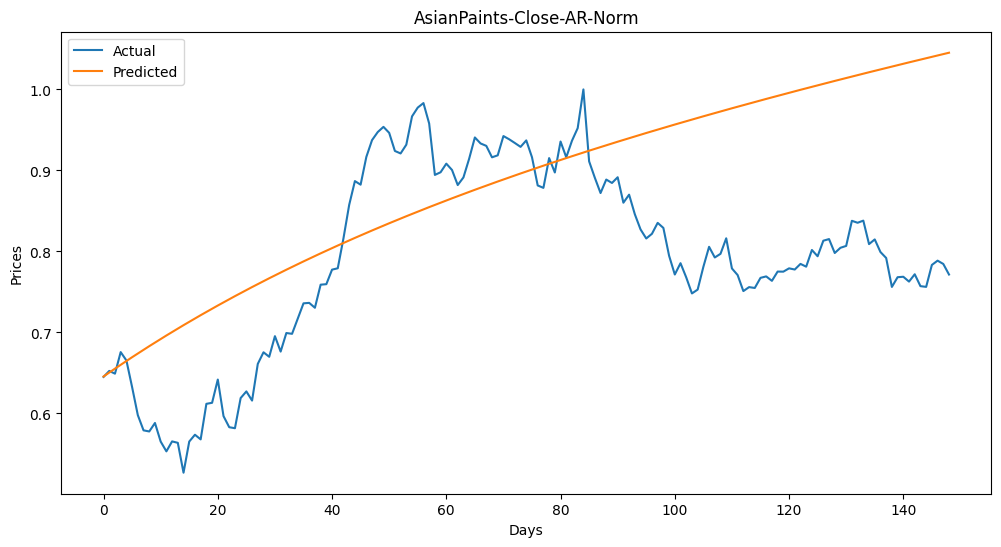

In [14]:
import matplotlib.pyplot as plt

def graph(y_true, y_pred, label_true, label_pred, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label=label_true)
    plt.plot(y_pred, label=label_pred)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "AsianPaints-Close-AR-Norm",
    "Days",
    "Prices"
)

| Code                                 | Purpose                                        |
| ------------------------------------ | ---------------------------------------------- |
| `import matplotlib.pyplot as plt`    | Imports Matplotlib library for plotting graphs |
| `def graph(...)`                     | Creates a reusable graph function              |
| `plt.figure(figsize=(12,6))`         | Sets graph size to 12 × 6 inches               |
| `plt.plot(y_true, label=label_true)` | Plots actual stock prices                      |
| `plt.plot(y_pred, label=label_pred)` | Plots predicted stock prices                   |
| `plt.title(title)`                   | Adds graph title                               |
| `plt.xlabel(xlabel)`                 | Sets X-axis label                              |
| `plt.ylabel(ylabel)`                 | Sets Y-axis label                              |
| `plt.legend()`                       | Displays legend (Actual vs Predicted)          |
| `plt.show()`                         | Displays the graph                             |
| `graph(...)`                         | Calls the function and generates the graph     |


In [15]:
len(data1)

747

total number of records (rows) in Asian Paints dataset.

There are 747 daily closing-price records available for Asian Paints from 2020–2023.

In [16]:
y_test

array([[0.64510773],
       [0.6525407 ],
       [0.64914473],
       [0.67576561],
       [0.66548282],
       [0.63249804],
       [0.59794549],
       [0.57918513],
       [0.57779989],
       [0.58828519],
       [0.56535647],
       [0.55324717],
       [0.56554731],
       [0.56378004],
       [0.52687914],
       [0.56533239],
       [0.57376362],
       [0.56803147],
       [0.61190671],
       [0.61319622],
       [0.64188105],
       [0.59676397],
       [0.58305452],
       [0.58181244],
       [0.61904781],
       [0.62724028],
       [0.61591914],
       [0.66120346],
       [0.67553383],
       [0.66999288],
       [0.6954296 ],
       [0.67639375],
       [0.69932247],
       [0.69834323],
       [0.71697284],
       [0.73593692],
       [0.73653424],
       [0.73049121],
       [0.7589852 ],
       [0.75960612],
       [0.77754317],
       [0.77923892],
       [0.81628321],
       [0.85753126],
       [0.88683725],
       [0.88244241],
       [0.91664435],
       [0.937

y_test contains the actual test values after normalization.

| Code     | Purpose                                             |
| -------- | --------------------------------------------------- |
| `y_test` | Stores actual stock prices from the testing dataset |
====

are scaled values between 0 and 1 because of:
Ms = MinMaxScaler()

In [53]:
rmsemape(y_test, y_pred)

RMSE = 0.17693804507577043
MAPE = 18.695226710314657



For the Asian Paints AR model, RMSE is 0.1769 and MAPE is 18.70%, indicating that the model can reasonably forecast stock price movements.

which is generally considered reasonable/good for stock-price forecasting.

| RMSE Value       | Interpretation               |
| ---------------- | ---------------------------- |
| RMSE = 0         | Perfect prediction           |
| RMSE < 0.1       | Excellent                    |
| 0.1 ≤ RMSE < 0.2 | Very Good                    |
| 0.2 ≤ RMSE < 0.5 | Good                         |
| 0.5 ≤ RMSE < 1.0 | Acceptable                   |
| RMSE > 1.0       | Poor (depends on data scale) |


| Variable | Meaning          |
| -------- | ---------------- |
| `y_test` | Actual values    |
| `y_pred` | Predicted values |


convert normalized stock prices back to original Asian Paints prices

In [17]:
import pandas as pd

def conversionSingle(data_array, columns):
    # Reshape if necessary to ensure it's 2D for inverse_transform
    if data_array.ndim == 1:
        data_array = data_array.reshape(-1, 1)

    # Inverse transform the data using the fitted MinMaxScaler (Ms)
    original_scale_data = Ms.inverse_transform(data_array)

    # Create a DataFrame with the original column names
    df = pd.DataFrame(original_scale_data, columns=columns)
    return df

asianPaints_TestNormTable = conversionSingle(
    y_test,
    [column]
)

| Code                                         | Purpose                                                   |
| -------------------------------------------- | --------------------------------------------------------- |
| `import pandas as pd`                        | Imports Pandas library for DataFrame creation             |
| `def conversionSingle(data_array, columns):` | Defines a reusable conversion function                    |
| `if data_array.ndim == 1:`                   | Checks whether input data is 1-dimensional                |
| `data_array.reshape(-1,1)`                   | Converts 1D array into 2D format required by MinMaxScaler |
| `Ms.inverse_transform(data_array)`           | Converts normalized values back to original stock prices  |
| `pd.DataFrame(...)`                          | Creates a DataFrame from the converted values             |
| `columns=columns`                            | Assigns the original column name (e.g., Close)            |
| `return df`                                  | Returns the converted DataFrame                           |


In [18]:
asianPaints_TestNormTable

,Close
0,2738.901367
1,2753.973145
2,2747.087158
3,2801.066162
4,2780.215820
...,...
144,2964.347412
145,3019.200195
146,3029.967285
147,3021.673828


In [54]:
print(y_test[0])

[0.64510773]


In [55]:
Ms.inverse_transform(y_test[:1])

array([[2738.90136719]])

In [56]:
print(y_test[1])

[0.6525407]


In [59]:
Ms.inverse_transform(y_test[:2])

array([[2738.90136719],
       [2753.97314453]])

In [19]:
actual_stock_price_test_ori=Ms.inverse_transform(asianPaints_TestNormTable)

| Code                          | Purpose                                           |
| ----------------------------- | ------------------------------------------------- |
| `Ms`                          | Trained MinMaxScaler object                       |
| `inverse_transform()`         | Converts normalized values back to original scale |
| `asianPaints_TestNormTable`   | Input normalized stock-price data                 |
| `actual_stock_price_test_ori` | Stores original stock prices after conversion     |


In [60]:
actual_stock_price_test_ori

array([[2738.90136719],
       [2753.97314453],
       [2747.0871582 ],
       [2801.06616211],
       [2780.21582031],
       [2713.33276367],
       [2643.27075195],
       [2605.23046875],
       [2602.42163086],
       [2623.68261719],
       [2577.19018555],
       [2552.63623047],
       [2577.57714844],
       [2573.99365234],
       [2499.16992188],
       [2577.14135742],
       [2594.23730469],
       [2582.61425781],
       [2671.57983398],
       [2674.19458008],
       [2732.35864258],
       [2640.875     ],
       [2613.07641602],
       [2610.55786133],
       [2686.05981445],
       [2702.67163086],
       [2679.71582031],
       [2771.53857422],
       [2800.59619141],
       [2789.36083984],
       [2840.9387207 ],
       [2802.33984375],
       [2848.83227539],
       [2846.84667969],
       [2884.62182617],
       [2923.07519531],
       [2924.28637695],
       [2912.03295898],
       [2969.81005859],
       [2971.0690918 ],
       [3007.43994141],
       [3010.878

| Code                          | Purpose                                  |
| ----------------------------- | ---------------------------------------- |
| `actual_stock_price_test_ori` | Displays the converted stock prices      |
| Output                        | Original Asian Paints closing prices (₹) |


In [21]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

| Code                           | Purpose                                            |
| ------------------------------ | -------------------------------------------------- |
| `conversionSingle()`           | Converts NumPy array into DataFrame                |
| `actual_stock_price_test_ori`  | Original stock prices after inverse transformation |
| `[column]`                     | Assigns column name (`Close`)                      |
| `actual_stock_price_test_oriA` | Stores actual stock prices in DataFrame format     |
========

Converts actual stock prices into a structured DataFrame for graph plotting and comparison.

In [61]:
print(stk_data[['Close']].head())
print(stk_data[['Close']].describe())

Price              Close
Ticker     ASIANPAINT.NS
Date                    
2020-01-01   1705.415527
2020-01-02   1702.990479
2020-01-03   1665.661743
2020-01-06   1623.577881
2020-01-07   1639.983398
Price          Close
Ticker ASIANPAINT.NS
count     747.000000
mean     2541.237197
std       591.720174
min      1430.820068
25%      1943.512512
50%      2735.193848
75%      3028.513062
max      3458.514404


| Statistic |   Value | Meaning             |
| --------- | ------: | ------------------- |
| count     |     747 | Total records       |
| mean      | 2541.24 | Average stock price |
| std       |  591.72 | Standard deviation  |
| min       | 1430.82 | Lowest price        |
| 25%       | 1943.51 | First quartile      |
| 50%       | 2735.19 | Median price        |
| 75%       | 3028.51 | Third quartile      |
| max       | 3458.51 | Highest price       |


| Code                  | Purpose                    |
| --------------------- | -------------------------- |
| `stk_data[['Close']]` | Selects Close price column |
| `.head()`             | Displays first 5 records   |
===

| Code          | Purpose                                       |
| ------------- | --------------------------------------------- |
| `.describe()` | Generates statistical summary of Close prices |


In [23]:
column = "Close"

data1 = stk_data[[column]]

from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()

data1 = Ms.fit_transform(data1)

| Code                                             | Purpose                                                   |
| ------------------------------------------------ | --------------------------------------------------------- |
| `column = "Close"`                               | Selects the Close price column from Asian Paints dataset  |
| `data1 = stk_data[[column]]`                     | Creates a new dataset containing only Close prices        |
| `from sklearn.preprocessing import MinMaxScaler` | Imports MinMaxScaler for normalization                    |
| `Ms = MinMaxScaler()`                            | Creates MinMaxScaler object                               |
| `Ms.fit_transform(data1)`                        | Learns min/max values and normalizes data between 0 and 1 |
| `data1 = ...`                                    | Stores normalized values in `data1`                       |

==========
| Without Normalization        | With Normalization       |
| ---------------------------- | ------------------------ |
| Large values (₹1700–₹3400)   | Values between 0 and 1   |
| Training may be slower       | Faster model training    |
| Difficult to compare scales  | Uniform scale            |
| Higher numerical instability | Better model performance |
========

The Close price column is selected and normalized using MinMaxScaler. The scaler converts all stock prices into the range 0 to 1 using the minimum and maximum values of the dataset. This improves model training efficiency and ensures that all observations are on the same scale before applying the AutoRegressive model.

In [62]:
print(Ms.data_min_)
print(Ms.data_max_)

[1430.82006836]
[3458.5144043]








| Code           | Purpose                                                 |
| -------------- | ------------------------------------------------------- |
| `Ms.data_min_` | Displays the minimum stock price used for normalization |
| `Ms.data_max_` | Displays the maximum stock price used for normalization |


In [25]:
actual_stock_price_test_ori = Ms.inverse_transform(y_test)

print(actual_stock_price_test_ori[:5])

[[2738.90136719]
 [2753.97314453]
 [2747.0871582 ]
 [2801.06616211]
 [2780.21582031]]


| Code                          | Purpose                                            |
| ----------------------------- | -------------------------------------------------- |
| `y_test`                      | Contains normalized test stock prices              |
| `Ms.inverse_transform()`      | Converts normalized values back to original prices |
| `actual_stock_price_test_ori` | Stores actual stock prices in ₹                    |
| `[:5]`                        | Displays first 5 records                           |

============

| Before Inverse Transform | After Inverse Transform |
| ------------------------ | ----------------------- |
| 0.6451                   | ₹2738.90                |
| 0.6525                   | ₹2753.97                |
| 0.6491                   | ₹2747.09                |


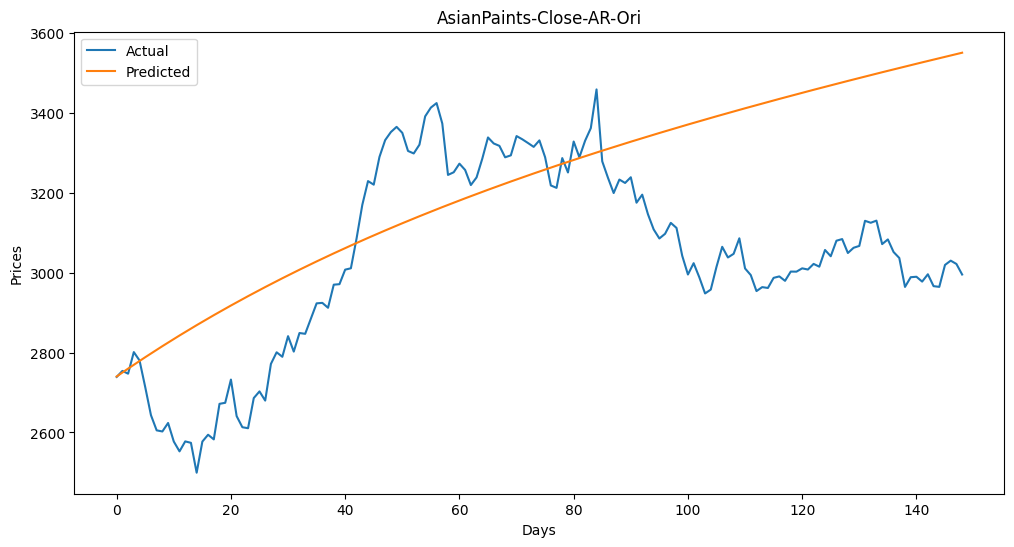

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the graph function locally, as stockFunctions was not found previously
def graph(y_true, y_pred, label_true, label_pred, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label=label_true)
    plt.plot(y_pred, label=label_pred)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

actual_stock_price_test_oriA = pd.DataFrame(
    actual_stock_price_test_ori,
    columns=[column]
)

# Inverse transform y_pred to get predicted_stock_price_test_ori
predicted_stock_price_test_ori = Ms.inverse_transform(y_pred.reshape(-1, 1)) # Reshape to 2D if necessary

predicted_stock_price_test_oriP = pd.DataFrame(
    predicted_stock_price_test_ori,
    columns=[column]
)

graph(
    actual_stock_price_test_oriA,
    predicted_stock_price_test_oriP,
    "Actual",
    "Predicted",
    "AsianPaints-Close-AR-Ori",
    "Days",
    "Prices"
)

In [27]:
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE = 294.7330157280813
MAPE = 8.267752578479923


In [28]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [29]:
forecast

array([1.04698603, 1.04866083, 1.05033059, 1.05199542])

In [33]:
fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = fTestNormTable.values
forecast_stock_price_test_oriF = fTestNormTable

In [35]:
forecast_stock_price_test_oriF

,Closefore
0,3553.787717
1,3557.183685
2,3560.569465
3,3563.945219


In [36]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

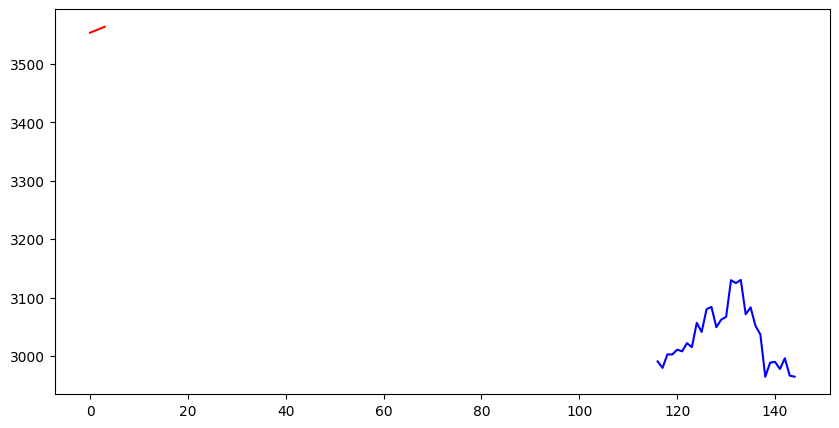

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")

In [38]:
trends=['c']
lags=[1,2,3,4]

for i in lags:

    model = AutoReg(
        X_train.flatten(),
        lags=i,
        trend='c'
    )

    model_fit = model.fit()

    y_pred = model_fit.predict(
        len(X_train),
        len(data1)-1
    )

    print("Lag =", i)

    rmsemape(
        y_test.flatten(),
        y_pred
    )

    print("****************")

Lag = 1
RMSE = 0.17693804507577043
MAPE = 18.19514299111569
****************
Lag = 2
RMSE = 0.17798132748833548
MAPE = 18.32291314356472
****************
Lag = 3
RMSE = 0.1787393254229307
MAPE = 18.41661563292901
****************
Lag = 4
RMSE = 0.17988276575563647
MAPE = 18.53141298604314
****************


In [39]:
i = 1
td = 'c'

model = AutoReg(
    X_train.flatten(),
    lags=i,
    trend=td
)

model_fit = model.fit()

Generate Predictions

In [40]:
y_pred = model_fit.predict(
    start=len(X_train),
    end=len(data1)-1
)

Check RMSE and MAPE

In [42]:
print("Lag={}, Trend={}".format(i, td))
rmsemape(y_test.flatten(), y_pred)

Lag=1, Trend=c
RMSE = 0.17693804507577043
MAPE = 18.19514299111569


Convert Actual Prices

In [43]:
actual_stock_price_test_ori = Ms.inverse_transform(y_test)

import pandas as pd

actual_stock_price_test_oriA = pd.DataFrame(
    actual_stock_price_test_ori,
    columns=[column]
)

actual_stock_price_test_oriA.head()

,Close
0,2738.901367
1,2753.973145
2,2747.087158
3,2801.066162
4,2780.215820


Convert Predicted Prices

In [44]:
predicted_stock_price_test_ori = Ms.inverse_transform(
    y_pred.reshape(-1,1)
)

predicted_stock_price_test_oriP = pd.DataFrame(
    predicted_stock_price_test_ori,
    columns=[column]
)

predicted_stock_price_test_oriP.head()

,Close
0,2730.558049
1,2731.024385
2,2731.488858
3,2731.951477
4,2732.412248


Actual vs Predicted Graph

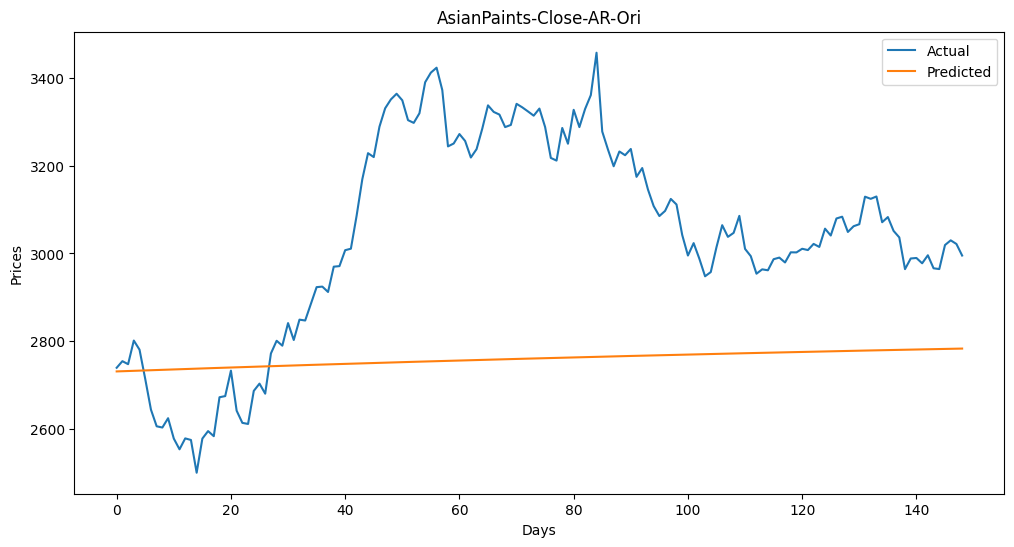

In [46]:
graph(
    actual_stock_price_test_oriA,
    predicted_stock_price_test_oriP,
    "Actual",
    "Predicted",
    "AsianPaints-Close-AR-Ori",
    "Days",
    "Prices"
)

Forecast Next 4 Days

In [47]:
forecast = model_fit.predict(
    len(data1),
    len(data1)+3
)

forecast

array([0.66685746, 0.66698416, 0.66711036, 0.66723604])

Convert Forecast Back

In [48]:
forecast_stock_price_test_ori = Ms.inverse_transform(
    forecast.reshape(-1,1)
)

forecast_stock_price_test_oriF = pd.DataFrame(
    forecast_stock_price_test_ori,
    columns=["Closefore"]
)

forecast_stock_price_test_oriF

,Closefore
0,2783.003170
1,2783.260077
2,2783.515958
3,2783.770817


In [49]:
forecast_stock_price_test_oriF

,Closefore
0,2783.003170
1,2783.260077
2,2783.515958
3,2783.770817


| Predicted                   | Forecast                       |
| --------------------------- | ------------------------------ |
| Predicts test data          | Predicts future data           |
| Actual values available     | Actual values unavailable      |
| Used for evaluation         | Used for future estimation     |
| RMSE/MAPE can be calculated | RMSE/MAPE cannot be calculated |
| `y_pred`                    | `forecast`                     |


Save Forecast CSV

In [50]:
forecast_stock_price_test_oriF.to_csv(
    "AsianPaints_Close_AR.csv",
    index=False
)

Plot Forecast Graph

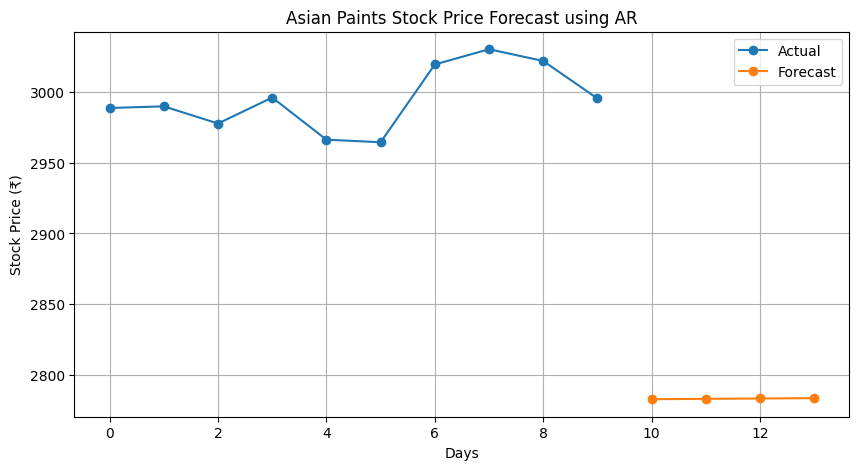

In [51]:
import matplotlib.pyplot as plt

recent_actual = actual_stock_price_test_oriA.tail(10)

plt.figure(figsize=(10,5))

plt.plot(
    range(10),
    recent_actual.iloc[:,0].values,
    marker='o',
    label='Actual'
)

plt.plot(
    range(10,14),
    forecast_stock_price_test_oriF["Closefore"].values,
    marker='o',
    label='Forecast'
)

plt.title("Asian Paints Stock Price Forecast using AR")
plt.xlabel("Days")
plt.ylabel("Stock Price (₹)")
plt.legend()
plt.grid(True)

plt.show()

Final Result Cell

In [52]:
print("Future Forecasted Prices for Asian Paints")
print()

print(forecast_stock_price_test_oriF)

Future Forecasted Prices for Asian Paints

     Closefore
0  2783.003170
1  2783.260077
2  2783.515958
3  2783.770817
